In [1]:
import matplotlib.pyplot as plt
plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True
    })


In [ ]:
import numpy as np
import pandas as pd
import uproot
from xgboost import XGBRegressor

# --- 1. 配置参数 ---
BASE_PATH = "/data/home/zzh/data/Dataset_Filted/CosmicRay"
FILES = {
    "proton": "QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root",
    "he":     "QF_He_addweight_rho_2.5e13_5.0e17_V3.root",
    "cno":    "QF_CNO_addweight_rho_2.5e13_5.0e17_V3.root",
    "fe":     "QF_Fe_addweight_rho_2.5e13_5.0e17_V3.root",
    "mgalsi": "QF_MgAlSi_addweight_rho_2.5e13_5.0e17_V3.root"
}

CUTS = (
    "rec_Eage > 0 and Redge > 0 and NuW3 > 0 and NpE3 > 250 "
    "and @theta_cut_low < rec_theta < @theta_cut_high"
)

# 阈值变量
r_cut_low, r_cut_high = 320, 420
theta_cut_low, theta_cut_high = np.deg2rad([10, 30])
log10TeV_low=2.76; log10TeV_high=3.16

# --- 2. 能量修正模型 ---
model = XGBRegressor();model._estimator_type = "regressor"
model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")

# --- 3. 核心处理函数 ---
def process_cosmic_ray(name, filename):
    with uproot.open(f"{BASE_PATH}/{filename}") as f:
        # 读取数据
        branches = ["E", "theta", "phi", "corex", "corey", "rec_x", "rec_y", 
                    "rec_theta", "rec_phi", "rec_Eage", "Redge", "NpE3", "NuM1", "NuW3", "weightGaisser"]
        df = f["Rec"].arrays(branches, library="pd")
        
        print(f"Processing {name}: Entries={len(df)}, Weights={df['weightGaisser'].sum():.2e}")

        # 1. 基础物理筛选
        df = df.query(CUTS).copy()
        
        # 2. 计算特征量
        df["R_ue"] = np.log10((1e-4 + df["NuM1"]) / (df["NpE3"]))
        df["r"] = np.hypot(df['rec_x'], df['rec_y']) # 比 sqrt(x^2+y^2) 更快
        
        # 3. 半径进一步筛选
        df = df[(df["r"] > r_cut_low) & (df["r"] < r_cut_high)]
        df['NuW3'] = np.log10(df['NuW3'])
        # 4. XGBoost 能量修正
        features = df[["NuW3", "rec_theta"]].values
        df["recE"] = model.predict(features)
        
        print(f"     Finished {name}: Remaining Entries={len(df)}")
        return df[(df['recE']>log10TeV_low) & (df['recE']<log10TeV_high)]

# --- 4. 批量执行 ---
dfs = {name: process_cosmic_ray(name, path) for name, path in FILES.items()}
# 如果你需要解包到独立变量（虽然推荐直接用字典 dfs['proton']）
proton_df, he_df, cno_df, fe_df, mgalsi_df = dfs.values()
df_all_components = pd.concat(dfs.values(), ignore_index=True)
df_all_components['Eage'] = df_all_components['rec_Eage'] 


Processing proton: Entries=14217778, Weights=1.90e+02
     Finished proton: Remaining Entries=767187
Processing he: Entries=14210418, Weights=2.03e+02
     Finished he: Remaining Entries=525865
Processing cno: Entries=14218958, Weights=7.65e+01
     Finished cno: Remaining Entries=398519
Processing fe: Entries=14217887, Weights=7.40e+01
     Finished fe: Remaining Entries=330377
Processing mgalsi: Entries=14220016, Weights=3.57e+01
     Finished mgalsi: Remaining Entries=364106


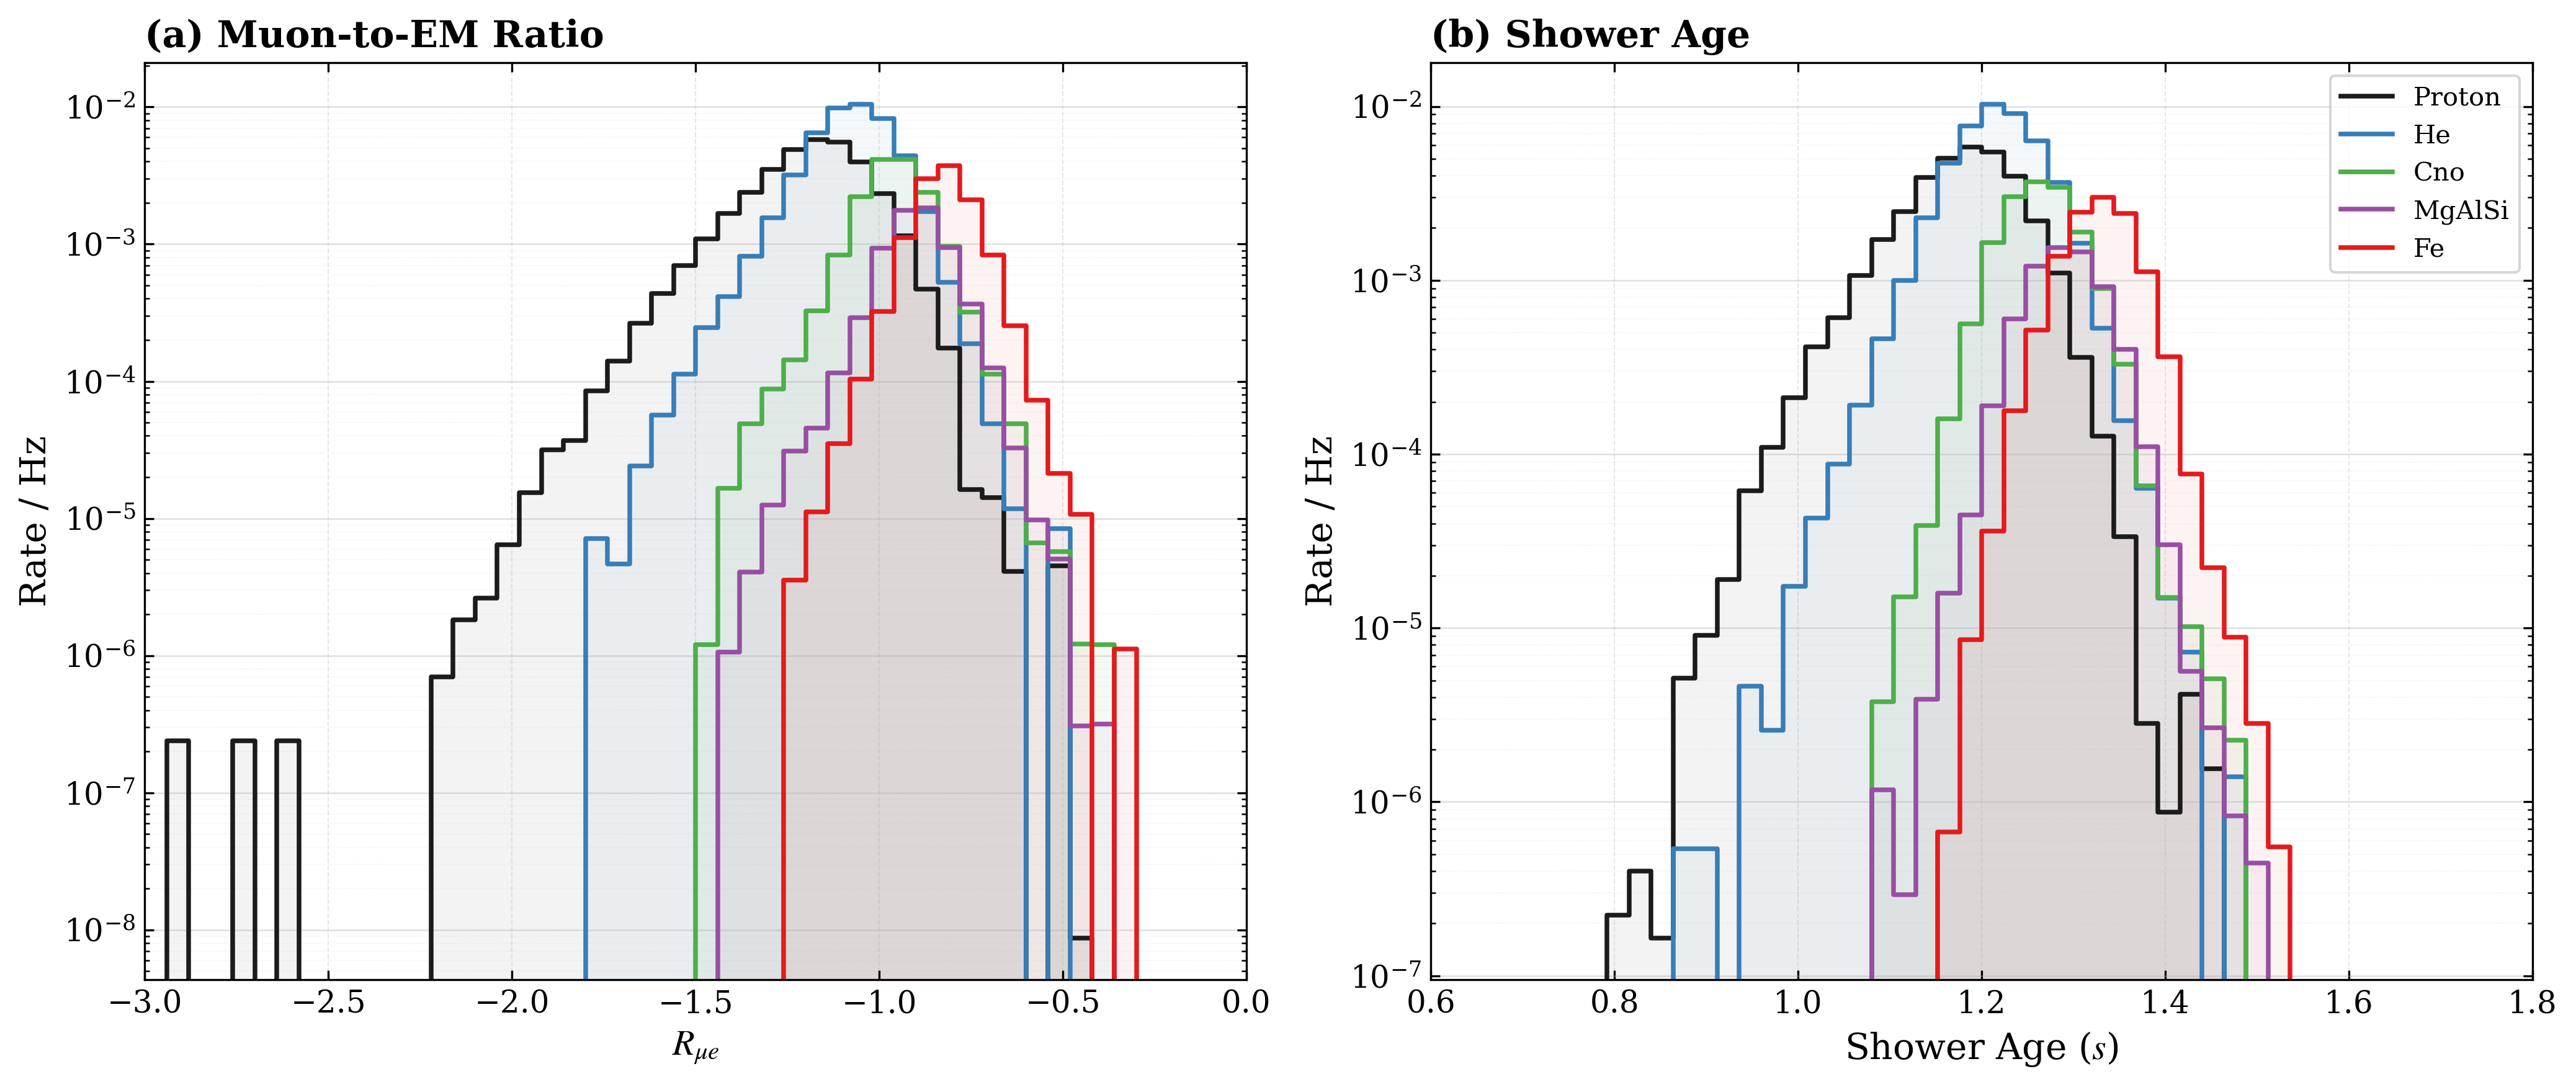

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import LogLocator, NullFormatter

def plot_composition_dual_panels(dfs, bins=50, figsize=(14, 6)):
    """
    绘制 R_ue 和 rec_Eage 的成分对比子图。
    要求：正式发表格式、加权统计、Y轴对数坐标及加密网格。
    """

    # 创建一个包含两个子图的图形对象，设置图形大小和分辨率
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=300)

    # 成分颜色映射
    # 方案 A：经典学术对比色
    color_map = {
    "proton": "#1B1B1B", # 黑色 (作为基准成分)
    "he":     "#377eb8", # 蓝色
    "cno":    "#4daf4a", # 绿色
    "mgalsi": "#984ea3", # 紫色
    "fe":     "#e41a1c"  # 红色
    }
    species_order = ["proton", "he", "cno", "mgalsi", "fe"]

    # 参数配置：(变量名, x范围, x轴标签)
    configs = [
        ("R_ue", (-3, 0), r"$R_{\mu e}$", ax1),
        ("rec_Eage", (0.6, 1.8), r"Shower Age ($s$)", ax2)
    ]

    for p_name, x_range, x_label, ax in configs:
        for name in species_order:
            if name not in dfs or p_name not in dfs[name].columns:
                continue
            
            df = dfs[name]
            # df=df[df['rec_Eage']<1.17]
            # 数据转换与权重提取
            vals = pd.to_numeric(df[p_name], errors='coerce').values
            weights = pd.to_numeric(df.get("weightGaisser", np.ones_like(vals)), errors='coerce').values
            
            # 过滤无效值
            mask = np.isfinite(vals) & np.isfinite(weights) & (vals >= x_range[0]) & (vals <= x_range[1])
            if not np.any(mask): continue

            # 计算加权直方图 (使用密度或计数，根据需求调整)
            counts, bin_edges = np.histogram(
                vals[mask], bins=bins, range=x_range, weights=weights[mask], 
            )
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            
            # 绘图
            label_text = name.capitalize() if name != "mgalsi" else "MgAlSi"
            ax.step(bin_edges[:-1], counts, where='post', label=label_text, 
                    color=color_map[name], linewidth=1.8)
            ax.fill_between(bin_edges[:-1], counts, step='post', color=color_map[name], alpha=0.05)

        # 2. 坐标轴与密集网格美化
        ax.set_xlabel(x_label, fontsize=14)
        ax.set_ylabel("Rate / Hz", fontsize=14)
        ax.set_xlim(x_range)
        ax.set_yscale('log')
        # ax.set_ylim(1e-6, ) # 根据数据密度调整

        # 设置 Y 轴主次加密网格
        ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
        ax.yaxis.set_minor_formatter(NullFormatter())

        # 线条样式：主网格实线，次网格极细点线
        ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.6, alpha=0.4)
        ax.grid(True, which='minor', axis='y', linestyle=':', linewidth=0.4, alpha=0.2)
        ax.grid(True, which='major', axis='x', linestyle='--', linewidth=0.5, alpha=0.3)

    # 3. 标注与保存
    ax1.set_title(r"(a) Muon-to-EM Ratio", loc='left', fontweight='bold')
    ax2.set_title(r"(b) Shower Age", loc='left', fontweight='bold')
    ax2.legend(frameon=True, fontsize=10, loc='upper right', ncol=1,  shadow=False).get_frame().set_edgecolor('0.8')

    plt.tight_layout()
    # plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/Composition_Rue_Age_Comparison.pdf", bbox_inches='tight')
    plt.show()

# 调用
plot_composition_dual_panels(dfs)


--- PROTON ---
Fit Range: (-1.9, -1.3)
Slope: 8.4263
Extrapolated Sum (Range (-4.0, -2.5)): 3.4139e-07 Hz
--- HE ---
Fit Range: (-1.6, -1.2)
Slope: 11.5243
Extrapolated Sum (Range (-4.0, -2.5)): 2.0541e-09 Hz

====== FINAL RESULT ======
Proton / Helium Ratio (in (-4.0, -2.5)): 166.1961


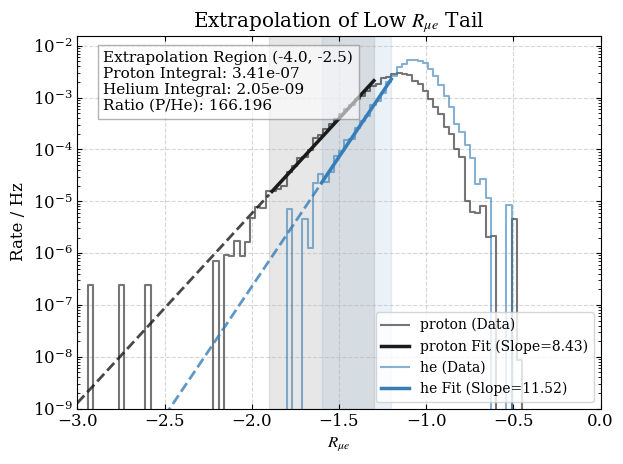

: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def analyze_and_plot_extrapolation(dfs, bins=100):
    # --- 1. 基础设置与绘图准备 (保持你的风格) ---

    
    fig, ax = plt.subplots()
    
    # 定义参数
    var_name = "R_ue"
    plot_range = (-3, 0)
    target_range = (-4.0, -2.5) # 我们要积分的目标区域
    
    # 拟合配置: (成分名, 拟合区间, 颜色)
    fit_configs = {
        "proton": {"fit_range": (-1.9, -1.3), "color": "#1B1B1B"},
        "he":     {"fit_range": (-1.6, -1.2), "color": "#377eb8"}
    }
    
    results = {}

    # --- 2. 循环处理 Proton 和 He ---
    for name, config in fit_configs.items():
        if name not in dfs: continue
        
        df = dfs[name]
        # df=df[df['rec_Eage']<1.15]
        vals = pd.to_numeric(df[var_name], errors='coerce').values
        weights = pd.to_numeric(df.get("weightGaisser", np.ones_like(vals)), errors='coerce').values
        
        # 2.1 获取直方图数据 (与画图保持一致)
        # 注意：这里 range 必须和画图时完全一致，保证 bin_width 相同
        counts, bin_edges = np.histogram(vals, bins=bins, range=plot_range, weights=weights)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        bin_width = bin_edges[1] - bin_edges[0]
        
        # 2.2 筛选拟合区间的数据
        fit_min, fit_max = config['fit_range']
        # 筛选条件：在拟合区间内 且 计数大于0 (log不接受0)
        mask = (bin_centers >= fit_min) & (bin_centers <= fit_max) & (counts > 0)
        
        x_fit = bin_centers[mask]
        y_fit = counts[mask] # 这里是 Rate
        
        if len(x_fit) < 2:
            print(f"Warning: Not enough points to fit {name}")
            continue

        # 2.3 线性拟合: ln(y) = slope * x + intercept
        # 对应物理模型: y = exp(intercept) * exp(slope * x)
        slope, intercept = np.polyfit(x_fit, np.log(y_fit), 1)
        
        # 定义拟合函数 (用于绘图和计算)
        def fitted_func(x):
            return np.exp(slope * x + intercept)
        
        # 2.4 积分计算目标区间 (-3, -2) 的总 Rate
        # 积分公式: Integral(e^(mx+c)) = (1/m) * [e^(mx+c)] | upper_lower
        # 重要：因为直方图是离散的 bin，拟合函数得到的是 "每个bin的计数"。
        # 该区间内的总数 ≈ 积分 / bin_width
        
        t_min, t_max = target_range
        integral_val = (fitted_func(t_max) - fitted_func(t_min)) / slope
        total_rate_extrapolated = integral_val / bin_width
        
        results[name] = {
            "total_rate": total_rate_extrapolated,
            "slope": slope,
            "intercept": intercept,
            "func": fitted_func
        }
        
        print(f"--- {name.upper()} ---")
        print(f"Fit Range: {config['fit_range']}")
        print(f"Slope: {slope:.4f}")
        print(f"Extrapolated Sum (Range {target_range}): {total_rate_extrapolated:.4e} Hz")

        # --- 3. 绘图部分 ---
        # 3.1 画原始阶梯图
        ax.step(bin_centers, counts, where='mid', label=f"{name}", 
                color=config['color'], alpha=0.6, linewidth=1.5)
        
        # 3.2 画拟合线 (延伸到左侧边界)
        x_plot = np.linspace(plot_range[0], fit_max, 100)
        y_plot = fitted_func(x_plot)
        
        # 实线表示拟合区间，虚线表示外推区间
        # 画外推段
        ax.plot(x_plot[x_plot < fit_min], y_plot[x_plot < fit_min], 
                linestyle="--", color=config['color'], alpha=0.8, linewidth=2)
        # 画拟合段 (加粗显示拟合依据)
        ax.plot(x_plot[(x_plot >= fit_min)], y_plot[(x_plot >= fit_min)], 
                linestyle="-", color=config['color'], linewidth=2.5, 
                label=f"{name} Fit (Slope={slope:.2f})")
        
        # 标记拟合区间区域
        ax.axvspan(fit_min, fit_max, color=config['color'], alpha=0.1)

    # --- 4. 计算并展示最终比值 ---
    if "proton" in results and "he" in results:
        ratio = results["proton"]["total_rate"] / results["he"]["total_rate"]
        print(f"\n====== FINAL RESULT ======")
        print(f"Proton / Helium Ratio (in {target_range}): {ratio:.4f}")
        
        # 在图上标注结果
        ax.text(0.05, 0.8, 
                f"Extrapolation Region {target_range}\n" + 
                f"Proton Integral: {results['proton']['total_rate']:.2e}\n" +
                f"Helium Integral: {results['he']['total_rate']:.2e}\n" +
                f"Ratio (P/He): {ratio:.3f}", 
                transform=ax.transAxes, fontsize=11,
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

    # 美化设置
    ax.set_yscale('log')
    ax.set_xlabel(r"$R_{\mu e}$")
    ax.set_ylabel("Rate / Hz")
    ax.set_title(r"Extrapolation of Low $R_{\mu e}$ Tail")
    ax.set_xlim(plot_range)
    # 自动调整ylim以显示外推线
    ax.set_ylim(bottom=1e-9) 
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(True, which="major", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# --- 执行 ---
# 假设 dfs 已经在内存中 (如你代码块所示)
analyze_and_plot_extrapolation(dfs)


In [2]:
import numpy as np
import pandas as pd
import uproot
from xgboost import XGBRegressor

# --- 1. 配置参数 ---
BASE_PATH = "/data/home/zzh/data/Dataset_Filted/CosmicRay"
FILES = {
    "proton": "QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root",
    "he":     "QF_He_addweight_rho_2.5e13_5.0e17_V3.root",
    "cno":    "QF_CNO_addweight_rho_2.5e13_5.0e17_V3.root",
    "fe":     "QF_Fe_addweight_rho_2.5e13_5.0e17_V3.root",
    "mgalsi": "QF_MgAlSi_addweight_rho_2.5e13_5.0e17_V3.root"
}

CUTS = (
    "rec_Eage > 0 and Redge > 0 and NuW3 > 0 and NpE3 > 250 "
    "and @theta_cut_low < rec_theta < @theta_cut_high"
)

# 阈值变量
r_cut_low, r_cut_high = 320, 420
theta_cut_low, theta_cut_high = np.deg2rad([10, 30])
log10TeV_low=1.84; log10TeV_high=2.1

# --- 2. 能量修正模型 ---
model = XGBRegressor();model._estimator_type = "regressor"
model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")

# --- 3. 核心处理函数 ---
def process_cosmic_ray(name, filename):
    with uproot.open(f"{BASE_PATH}/{filename}") as f:
        # 读取数据
        branches = ["E", "theta", "phi", "corex", "corey", "rec_x", "rec_y", 
                    "rec_theta", "rec_phi", "rec_Eage", "Redge", "NpE3", "NuM1", "NuW3", "weightGaisser"]
        df = f["Rec"].arrays(branches, library="pd")
        
        print(f"Processing {name}: Entries={len(df)}, Weights={df['weightGaisser'].sum():.2e}")

        # 1. 基础物理筛选
        df = df.query(CUTS).copy()
        
        # 2. 计算特征量
        df["R_ue"] = np.log10((1e-4 + df["NuM1"]) / (df["NpE3"]))
        df["r"] = np.hypot(df['rec_x'], df['rec_y']) # 比 sqrt(x^2+y^2) 更快
        
        # 3. 半径进一步筛选
        df = df[(df["r"] > r_cut_low) & (df["r"] < r_cut_high)]
        df['NuW3'] = np.log10(df['NuW3'])
        # 4. XGBoost 能量修正
        features = df[["NuW3", "rec_theta"]].values
        df["recE"] = model.predict(features)
        
        print(f"     Finished {name}: Remaining Entries={len(df)}")
        return df[(df['recE']>log10TeV_low) & (df['recE']<log10TeV_high)]

# --- 4. 批量执行 ---
dfs = {name: process_cosmic_ray(name, path) for name, path in FILES.items()}
# 如果你需要解包到独立变量（虽然推荐直接用字典 dfs['proton']）
proton_df, he_df, cno_df, fe_df, mgalsi_df = dfs.values()
df_all_components = pd.concat(dfs.values(), ignore_index=True)
df_all_components['Eage'] = df_all_components['rec_Eage'] 


Processing proton: Entries=14217778, Weights=1.90e+02
     Finished proton: Remaining Entries=767187
Processing he: Entries=14210418, Weights=2.03e+02
     Finished he: Remaining Entries=525865
Processing cno: Entries=14218958, Weights=7.65e+01
     Finished cno: Remaining Entries=398519
Processing fe: Entries=14217887, Weights=7.40e+01
     Finished fe: Remaining Entries=330377
Processing mgalsi: Entries=14220016, Weights=3.57e+01
     Finished mgalsi: Remaining Entries=364106


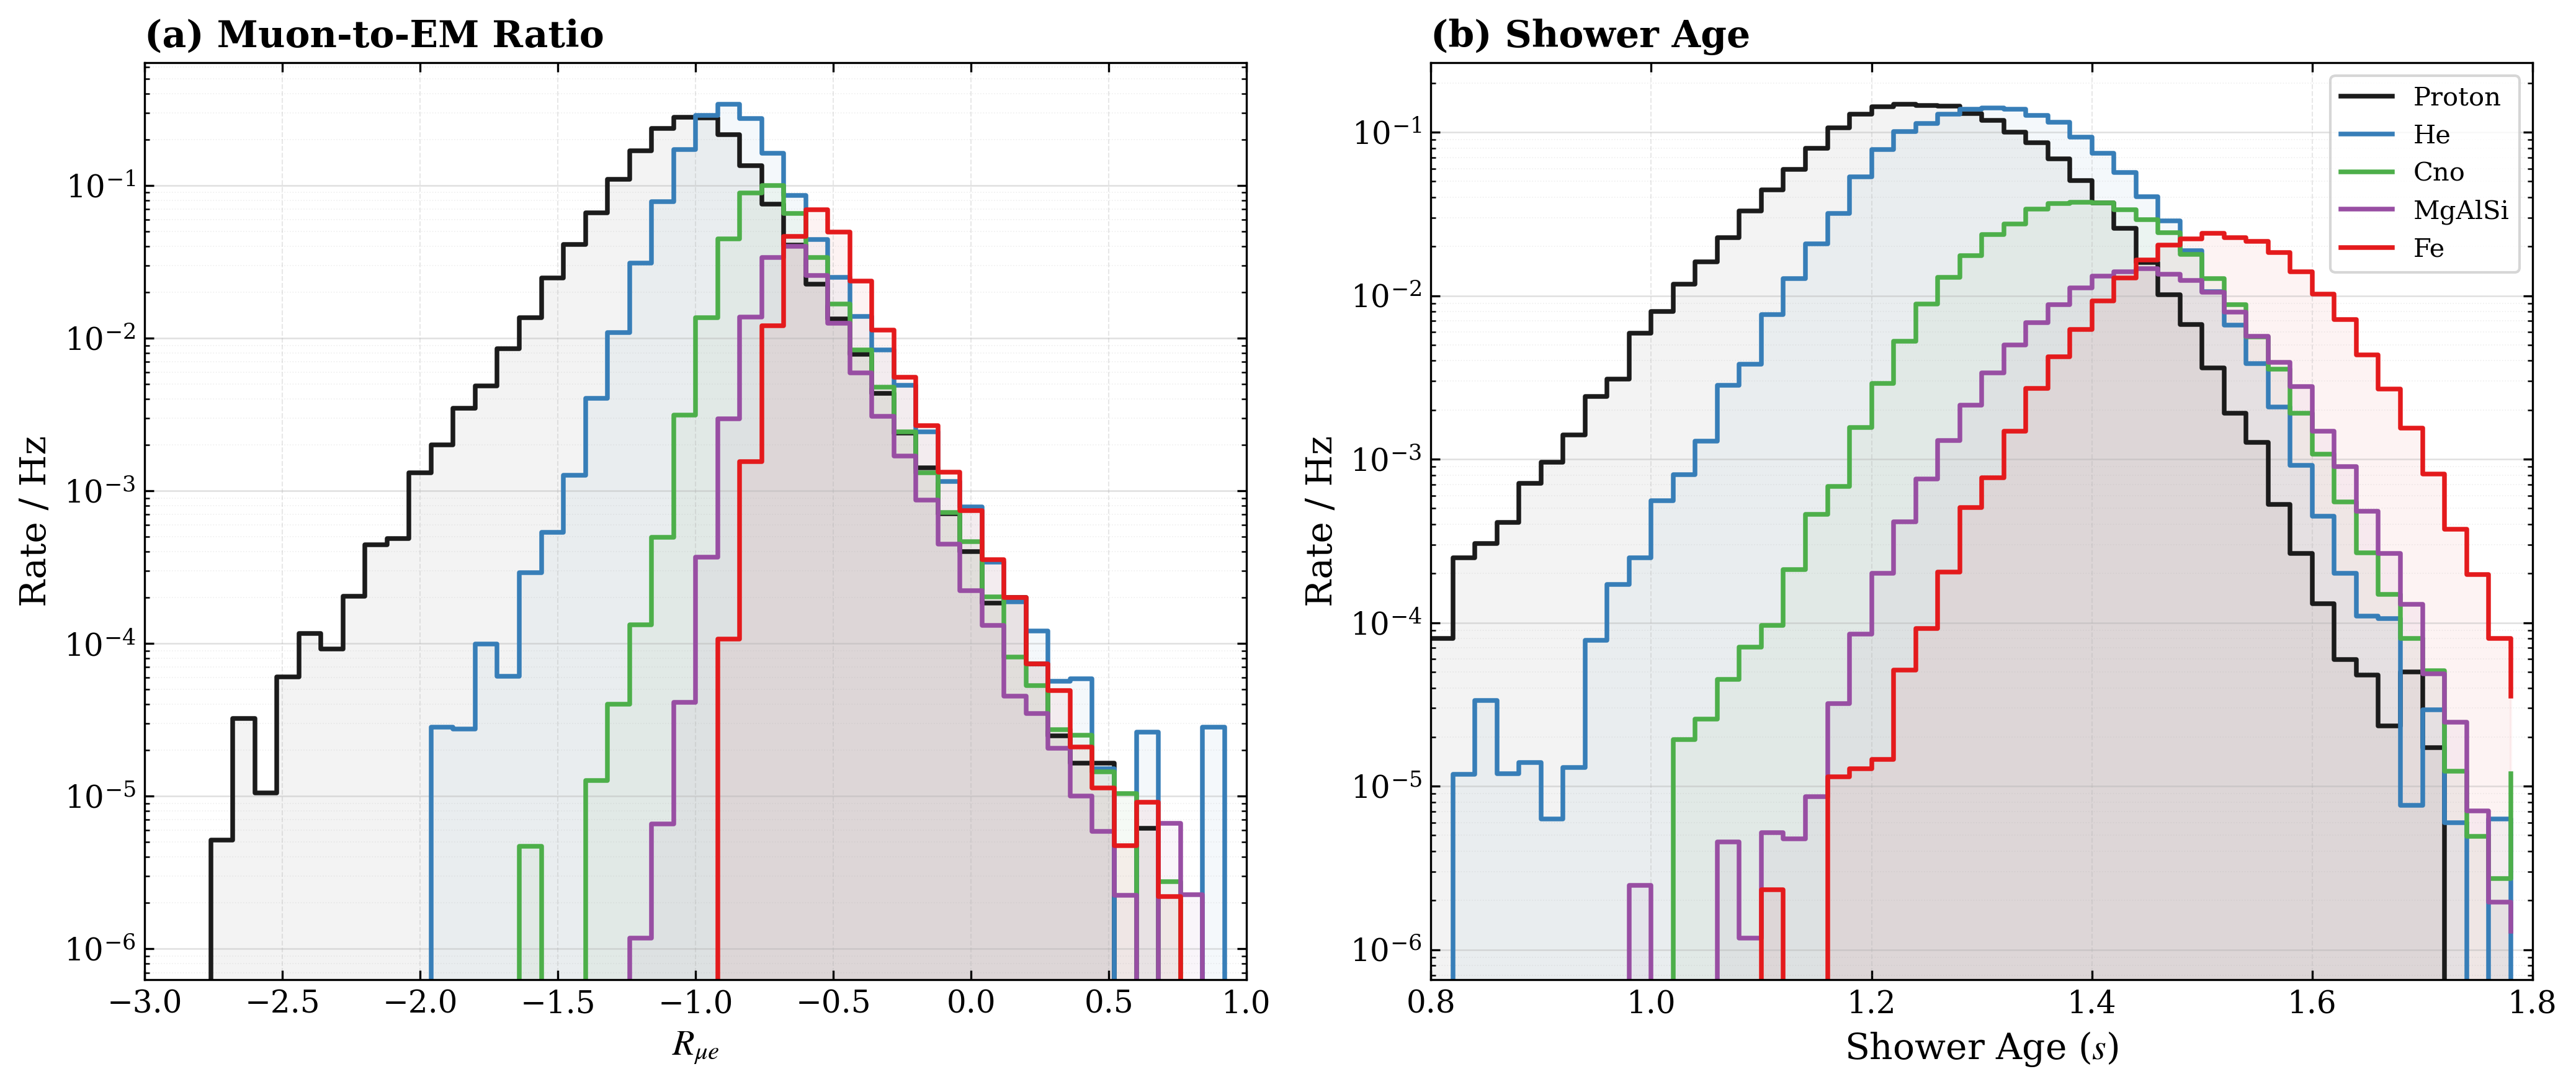

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import LogLocator, NullFormatter

def plot_composition_dual_panels(dfs, bins=50, figsize=(14, 6)):
    """
    绘制 R_ue 和 rec_Eage 的成分对比子图。
    要求：正式发表格式、加权统计、Y轴对数坐标及加密网格。
    """

    # 创建一个包含两个子图的图形对象，设置图形大小和分辨率
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=300)

    # 成分颜色映射
    # 方案 A：经典学术对比色
    color_map = {
    "proton": "#1B1B1B", # 黑色 (作为基准成分)
    "he":     "#377eb8", # 蓝色
    "cno":    "#4daf4a", # 绿色
    "mgalsi": "#984ea3", # 紫色
    "fe":     "#e41a1c"  # 红色
    }
    species_order = ["proton", "he", "cno", "mgalsi", "fe"]

    # 参数配置：(变量名, x范围, x轴标签)
    configs = [
        ("R_ue", (-3, 1), r"$R_{\mu e}$", ax1),
        ("rec_Eage", (0.8, 1.8), r"Shower Age ($s$)", ax2)
    ]

    for p_name, x_range, x_label, ax in configs:
        for name in species_order:
            if name not in dfs or p_name not in dfs[name].columns:
                continue
            
            df = dfs[name]
            # df=df[df['rec_Eage']<1.17]
            # 数据转换与权重提取
            vals = pd.to_numeric(df[p_name], errors='coerce').values
            weights = pd.to_numeric(df.get("weightGaisser", np.ones_like(vals)), errors='coerce').values
            
            # 过滤无效值
            mask = np.isfinite(vals) & np.isfinite(weights) & (vals >= x_range[0]) & (vals <= x_range[1])
            if not np.any(mask): continue

            # 计算加权直方图 (使用密度或计数，根据需求调整)
            counts, bin_edges = np.histogram(
                vals[mask], bins=bins, range=x_range, weights=weights[mask], 
            )
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            
            # 绘图
            label_text = name.capitalize() if name != "mgalsi" else "MgAlSi"
            ax.step(bin_edges[:-1], counts, where='post', label=label_text, 
                    color=color_map[name], linewidth=1.8)
            ax.fill_between(bin_edges[:-1], counts, step='post', color=color_map[name], alpha=0.05)

        # 2. 坐标轴与密集网格美化
        ax.set_xlabel(x_label, fontsize=14)
        ax.set_ylabel("Rate / Hz", fontsize=14)
        ax.set_xlim(x_range)
        ax.set_yscale('log')
        # ax.set_ylim(1e-6, ) # 根据数据密度调整

        # 设置 Y 轴主次加密网格
        ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
        ax.yaxis.set_minor_formatter(NullFormatter())

        # 线条样式：主网格实线，次网格极细点线
        ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.6, alpha=0.4)
        ax.grid(True, which='minor', axis='y', linestyle=':', linewidth=0.4, alpha=0.2)
        ax.grid(True, which='major', axis='x', linestyle='--', linewidth=0.5, alpha=0.3)

    # 3. 标注与保存
    ax1.set_title(r"(a) Muon-to-EM Ratio", loc='left', fontweight='bold')
    ax2.set_title(r"(b) Shower Age", loc='left', fontweight='bold')
    ax2.legend(frameon=True, fontsize=10, loc='upper right', ncol=1,  shadow=False).get_frame().set_edgecolor('0.8')

    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/Composition_Rue_Age_Comparison.pdf", bbox_inches='tight')
    plt.show()

# 调用
plot_composition_dual_panels(dfs)


--- PROTON ---
Fit Range: (-2.3, -1.3)
Slope: 6.7674
Extrapolated Sum (Range (-4.0, -2.84)): 6.0811e-06 Hz
--- HE ---
Fit Range: (-1.8, -1.1)
Slope: 11.0570
Extrapolated Sum (Range (-4.0, -2.84)): 3.7179e-10 Hz

====== FINAL RESULT ======
Proton / Helium Ratio (in (-4.0, -2.84)): 16356.0820


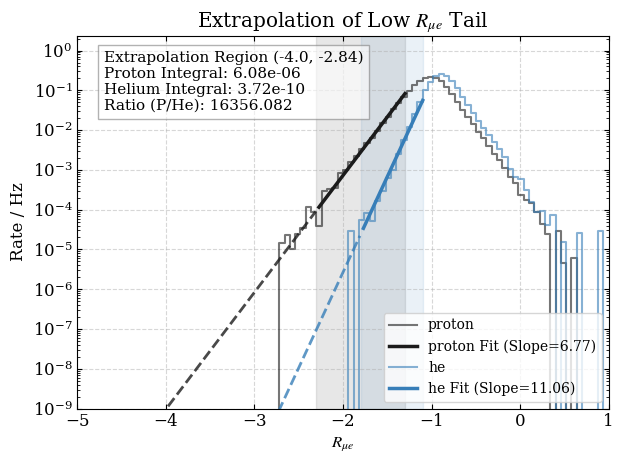

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def analyze_and_plot_extrapolation(dfs, bins=100):
    # --- 1. 基础设置与绘图准备 (保持你的风格) ---

    
    fig, ax = plt.subplots()
    
    # 定义参数
    var_name = "R_ue"
    plot_range = (-5, 1)
    target_range = (-4.0, -2.84) # 我们要积分的目标区域
    
    # 拟合配置: (成分名, 拟合区间, 颜色)
    fit_configs = {
        "proton": {"fit_range": (-2.3, -1.3), "color": "#1B1B1B"},
        "he":     {"fit_range": (-1.8, -1.1), "color": "#377eb8"}
    }
    
    results = {}

    # --- 2. 循环处理 Proton 和 He ---
    for name, config in fit_configs.items():
        if name not in dfs: continue
        
        df = dfs[name]
        # df=df[df['rec_Eage']<1.15]
        vals = pd.to_numeric(df[var_name], errors='coerce').values
        weights = pd.to_numeric(df.get("weightGaisser", np.ones_like(vals)), errors='coerce').values
        
        # 2.1 获取直方图数据 (与画图保持一致)
        # 注意：这里 range 必须和画图时完全一致，保证 bin_width 相同
        counts, bin_edges = np.histogram(vals, bins=bins, range=plot_range, weights=weights)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        bin_width = bin_edges[1] - bin_edges[0]
        
        # 2.2 筛选拟合区间的数据
        fit_min, fit_max = config['fit_range']
        # 筛选条件：在拟合区间内 且 计数大于0 (log不接受0)
        mask = (bin_centers >= fit_min) & (bin_centers <= fit_max) & (counts > 0)
        
        x_fit = bin_centers[mask]
        y_fit = counts[mask] # 这里是 Rate
        
        if len(x_fit) < 2:
            print(f"Warning: Not enough points to fit {name}")
            continue

        # 2.3 线性拟合: ln(y) = slope * x + intercept
        # 对应物理模型: y = exp(intercept) * exp(slope * x)
        slope, intercept = np.polyfit(x_fit, np.log(y_fit), 1)
        
        # 定义拟合函数 (用于绘图和计算)
        def fitted_func(x):
            return np.exp(slope * x + intercept)
        
        # 2.4 积分计算目标区间 (-3, -2) 的总 Rate
        # 积分公式: Integral(e^(mx+c)) = (1/m) * [e^(mx+c)] | upper_lower
        # 重要：因为直方图是离散的 bin，拟合函数得到的是 "每个bin的计数"。
        # 该区间内的总数 ≈ 积分 / bin_width
        
        t_min, t_max = target_range
        integral_val = (fitted_func(t_max) - fitted_func(t_min)) / slope
        total_rate_extrapolated = integral_val / bin_width
        
        results[name] = {
            "total_rate": total_rate_extrapolated,
            "slope": slope,
            "intercept": intercept,
            "func": fitted_func
        }
        
        print(f"--- {name.upper()} ---")
        print(f"Fit Range: {config['fit_range']}")
        print(f"Slope: {slope:.4f}")
        print(f"Extrapolated Sum (Range {target_range}): {total_rate_extrapolated:.4e} Hz")

        # --- 3. 绘图部分 ---
        # 3.1 画原始阶梯图
        ax.step(bin_centers, counts, where='mid', label=f"{name}", 
                color=config['color'], alpha=0.6, linewidth=1.5)
        
        # 3.2 画拟合线 (延伸到左侧边界)
        x_plot = np.linspace(plot_range[0], fit_max, 100)
        y_plot = fitted_func(x_plot)
        
        # 实线表示拟合区间，虚线表示外推区间
        # 画外推段
        ax.plot(x_plot[x_plot < fit_min], y_plot[x_plot < fit_min], 
                linestyle="--", color=config['color'], alpha=0.8, linewidth=2)
        # 画拟合段 (加粗显示拟合依据)
        ax.plot(x_plot[(x_plot >= fit_min)], y_plot[(x_plot >= fit_min)], 
                linestyle="-", color=config['color'], linewidth=2.5, 
                label=f"{name} Fit (Slope={slope:.2f})")
        
        # 标记拟合区间区域
        ax.axvspan(fit_min, fit_max, color=config['color'], alpha=0.1)

    # --- 4. 计算并展示最终比值 ---
    if "proton" in results and "he" in results:
        ratio = results["proton"]["total_rate"] / results["he"]["total_rate"]
        print(f"\n====== FINAL RESULT ======")
        print(f"Proton / Helium Ratio (in {target_range}): {ratio:.4f}")
        
        # 在图上标注结果
        ax.text(0.05, 0.8, 
                f"Extrapolation Region {target_range}\n" + 
                f"Proton Integral: {results['proton']['total_rate']:.2e}\n" +
                f"Helium Integral: {results['he']['total_rate']:.2e}\n" +
                f"Ratio (P/He): {ratio:.3f}", 
                transform=ax.transAxes, fontsize=11,
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

    # 美化设置
    ax.set_yscale('log')
    ax.set_xlabel(r"$R_{\mu e}$")
    ax.set_ylabel("Rate / Hz")
    ax.set_title(r"Extrapolation of Low $R_{\mu e}$ Tail")
    ax.set_xlim(plot_range)
    # 自动调整ylim以显示外推线
    ax.set_ylim(bottom=1e-9) 
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(True, which="major", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_Rue_Extrapolation_Proton_He.pdf", bbox_inches='tight')
    plt.show()

# --- 执行 ---
# 假设 dfs 已经在内存中 (如你代码块所示)
analyze_and_plot_extrapolation(dfs)
